# Chi-Squared Test

A Chi-Squared test needs you to organize the data into a chart whether you are using Excel or Python. Let's use the diabetes data to see how to do this organization in Python. 

## Load Data

In [1]:
import pandas as pd
import os

diabetes_file_path = os.path.join(os.getcwd(), 'datasets', 'Diabetes_and_LifeStyle_Dataset.csv')
diabetes_df = pd.read_csv(diabetes_file_path)

## Hypotheses

$H_0$: There is no difference in diabetes rate between people of different income levels. <br>
$H_1$: There is a difference in diabetes rate for people in at least one income level. 

## Contingency Table

Our function will want a singular object (like a dataframe), so we'd like to make a contingincy table like this:

|             | Low | Lower-Middle | Middle | Upper-Middle | High |
| :---        | :--- | :---        | :---   | :---         | :--- |
| Diabetes    |  #   |       #       |    #    |        #      |   #   |
| No Diabetes |  #   |       #       |    #    |        #      |   #   |

I find it easiest to build the dataframe by rows, so let's split our data into people with and without diabetes to represent each row, then only take the 'income_level' column since that is what we care about. 

In [2]:
diabetes_only_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 1].copy()
diabetes_income_series = diabetes_only_df['income_level']

no_diabetes_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 0].copy()
no_diabetes_income_series = no_diabetes_df['income_level']

We can now use series.value_counts() to count how many of each value is in our series. We can also attach .reindex so the output is in our expected order of Low, Lower-Middle, Middle, Upper-Middle, and High. 

In [3]:
income_categories = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']
diabetes_col = diabetes_income_series.value_counts().reindex(income_categories)
no_diabetes_col = no_diabetes_income_series.value_counts().reindex(income_categories)

Now let's put our columns together to form rows for our DataFrame. 

In [4]:
# Concat lets us stack our data to build the dataframe
# axis=1 tells it to stack these array-like objects as columns
# keys defines the names of our columns
# .T takes the transpose, which turns our columns into rows
diabetes_contingency_table = pd.concat([diabetes_col, no_diabetes_col], axis=1, keys=['Diabetes', 'No Diabetes']).T

In [5]:
diabetes_contingency_table

income_level,Low,Lower-Middle,Middle,Upper-Middle,High
Diabetes,8662,14776,20423,11568,2953
No Diabetes,5760,9691,13791,7766,1907


## Test Statistic and P-Value

In [6]:
from scipy.stats import chi2_contingency

chi_squared, p_value, degrees_of_freedom, expected_freq = chi2_contingency(diabetes_contingency_table)
print(f'Chi-Squared: {round(chi_squared, 3)}')
print(f'p-value: {round(p_value, 3)}')

Chi-Squared: 4.338
p-value: 0.362


## Formal Result

Since p-value > 0.05, we fail to reject the null hypothesis that there is no difference in diabetes rate between people of different income levels.

## Meaning

Our sample suggests the rate of diabetes is the same for people of different income levels. 

## Bonus Visualization

There is no statistical difference in diabetes rate between different income levels, but what are our sample rates by income level? Let's visualize it with a horizontal bar chart.

In [7]:
bar_chart_df = diabetes_contingency_table.copy()

# Create a total row for our bar chart
bar_chart_df.loc['Total'] = bar_chart_df.sum(axis=0)
# Create a percent row for our bar chart
bar_chart_df.loc['% w/ Diabetes'] = (bar_chart_df.loc['Diabetes'] / bar_chart_df.loc['Total'])*100

In [8]:
bar_chart_df

income_level,Low,Lower-Middle,Middle,Upper-Middle,High
Diabetes,8662.000000,14776.000000,20423.000000,11568.00000,2953.000000
No Diabetes,5760.000000,9691.000000,13791.000000,7766.00000,1907.000000
Total,14422.000000,24467.000000,34214.000000,19334.00000,4860.000000
% w/ Diabetes,60.061018,60.391548,59.691939,59.83242,60.761317


<Axes: xlabel='% w/ Diabetes', ylabel='income_level'>

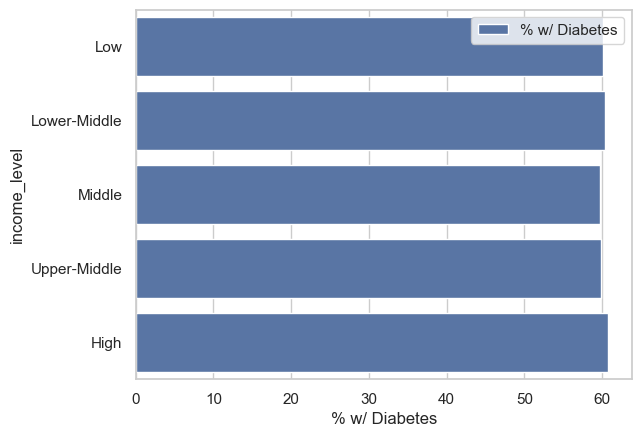

In [9]:
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.barplot(x="% w/ Diabetes", y="income_level", data=bar_chart_df.T,
            label="% w/ Diabetes", color="b")

Scaling each group by its total size makes it clear the rates of diabetes are approximately the same for all groups. What happens if we don't do this scaling? 

<Axes: xlabel='Total', ylabel='income_level'>

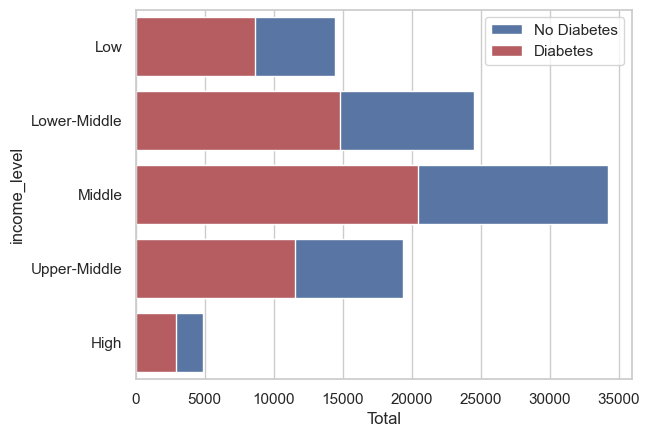

In [10]:
# By graphing the total first then the diabetes on top, the uncovered portion is "no diabetes"
sns.barplot(x="Total", y="income_level", data=bar_chart_df.T,
            label="No Diabetes", color="b")
sns.barplot(x="Diabetes", y="income_level", data=bar_chart_df.T,
            label="Diabetes", color="r")

We can see that scaling allowed us to easily compare groups of different sizes! Without scaling, it isn't as clear the diabetes rate is the same for all income levels.